In [2]:
import numpy as np
import pandas as pd

In [3]:
df=pd.read_csv(r'downloads\archive (2)\WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [4]:
#Check datatypes
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

<p style="color:red">gender              Female/Male<br>
Partner             Yes/No<br>
Dependents          Yes/No<br>
<br>
PhoneService        Yes/No<br>
MultipleLines       Yes/No/No phone service<br>
<br>
InternetService     DSL/Fiber optic/No<br>
OnlineSecrity       Yes/No/No internet service<br>
OnlineBackup        Yes/No/No internet service<br>
DeviceProtection    Yes/No/No internet service<br>
TechSupport         Yes/No/No internet service<br>
StreamingTV         Yes/No/No internet service<br>
StreamingMovies     Yes/No/No internet service<br>
<br>
Contract            Month-to-month/One year/Two year<br>
<br>
PaperlessBilling    Yes/No<br>
<br>
PaymentMethod       Electronic check/Mailed check/Bank transfer (automatic)/Credit card (automatic)<br>
<br>
TotalCharges        float but listed as object<br>
<br>
Churn               Yes/No<br></p>


In [5]:
df['TotalCharges']=df['TotalCharges'].astype(float)

ValueError: could not convert string to float: ' '

wierd values confirmed

In [ ]:
#pd.to_numeric to convert the non-convertible values to NaN

In [6]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [7]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [8]:
#Checking total number of null values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [9]:
#Filtering dataframes to get the null values columns
df[df['TotalCharges'].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


all 11 NaN values have tenure=0 indicating they are new customers. so filling their values with 0

In [10]:
df.loc[df['TotalCharges'].isna(),'TotalCharges']=0

In [11]:
#Checking null vales again
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

No more null values and incorrect data types

<h1>Exploratory Data Analysis</h1>

In [13]:
#Check no. of customers who left vs stayed
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Huge difference making the output imbalanced

In [14]:
#Finding tenure average for churned and non-churned customers

print("Average tenure of customers who left:",df[df["Churn"]=="Yes"]["tenure"].mean())
print("Average tenure of customers who stayed:",df[df["Churn"]=="No"]["tenure"].mean())

Average tenure of customers who left: 17.979133226324237
Average tenure of customers who stayed: 37.56996521066873


Customers who leave usually do so in 1st 18 months.

In [15]:
#Finding MonthlyCharges average for churned vs non-churned customers

print("Average Monthly Charges of customers who left:",df[df["Churn"]=="Yes"]["MonthlyCharges"].mean())
print("Average Monthly Charges of customers who stayed:",df[df["Churn"]=="No"]["MonthlyCharges"].mean())

Average Monthly Charges of customers who left: 74.44133226324237
Average Monthly Charges of customers who stayed: 61.26512369540008


As expected customers who pay higher tends to leave

In [16]:
#Finding relationship between contract and churn
print("Customers who left:\n",df[df["Churn"]=="Yes"]["Contract"].value_counts(normalize=True)*100)
print("\nCustomer who stayed:\n",df[df["Churn"]=="No"]["Contract"].value_counts(normalize=True)*100)

Customers who left:
 Contract
Month-to-month    88.550027
One year           8.881755
Two year           2.568218
Name: proportion, dtype: float64

Customer who stayed:
 Contract
Month-to-month    42.906842
Two year          31.832238
One year          25.260920
Name: proportion, dtype: float64


In [17]:
#Finding overall percentage of churn vs contract
pd.crosstab(df["Contract"],df["Churn"],normalize=True)*100

Churn,No,Yes
Contract,,
Month-to-month,31.520659,23.498509
One year,18.557433,2.356950
Two year,23.384921,0.681528


Month to Month Customers have higher probability to leave


### Visualizing the above results

In [18]:
import matplotlib.pyplot as plt

Text(0, 0.5, '')

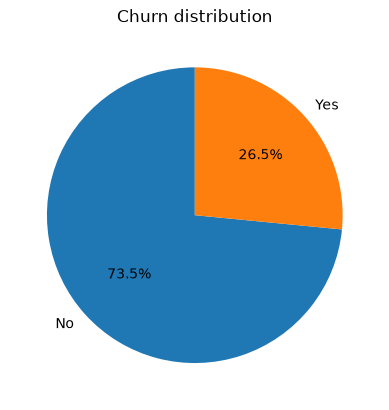

In [19]:
#plotting churn counts
churn_counts=df["Churn"].value_counts()
churn_counts.plot(kind='pie',autopct="%1.1f%%",startangle=90)
plt.title("Churn distribution")
plt.ylabel('')


Text(0, 0.5, 'Average tenure(in Months)')

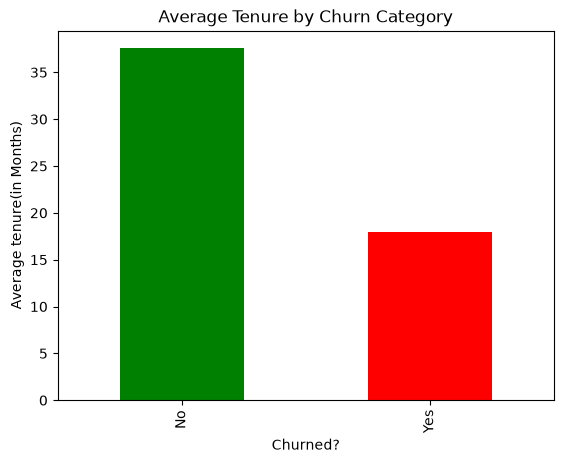

In [20]:
#plotting tenure vs churn
avg_tenure=df.groupby("Churn")["tenure"].mean()
avg_tenure.plot(kind="bar",color=["Green","Red"])
plt.title("Average Tenure by Churn Category")
plt.xlabel("Churned?")
plt.ylabel("Average tenure(in Months)")


Text(0, 0.5, 'Average Monthly Charges(in $)')

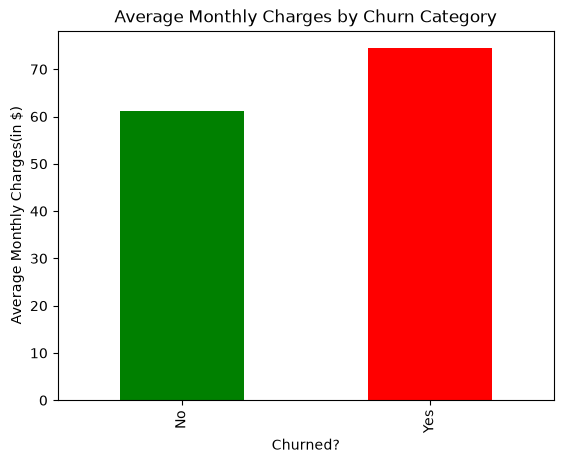

In [21]:
#plotting monthly charges vs churn
avg_monthlyCharges=df.groupby("Churn")["MonthlyCharges"].mean()
avg_monthlyCharges.plot(kind="bar",color=["Green","Red"])
plt.title("Average Monthly Charges by Churn Category")
plt.xlabel("Churned?")
plt.ylabel("Average Monthly Charges(in $)")

Text(0, 0.5, '')

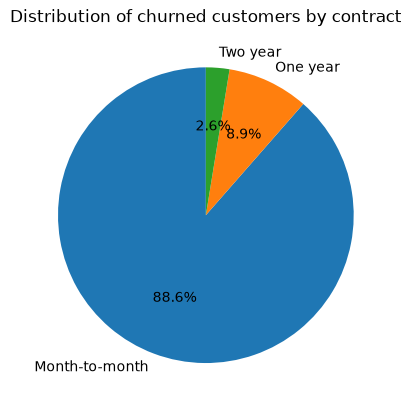

In [22]:
#plotting contract type rate for churned customers
contract_churned=df[df["Churn"]=="Yes"].groupby("Contract").size()
contract_churned.plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Distribution of churned customers by contract")
plt.ylabel('')


Text(0, 0.5, '')

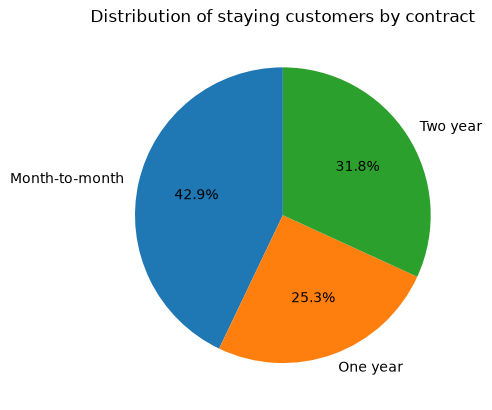

In [23]:
#plotting contract type for non-churned customers
contract_not_churned=df[df["Churn"]=="No"].groupby("Contract").size()
contract_not_churned.plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Distribution of staying customers by contract")
plt.ylabel('')

<b><p style="color:red">Customers in their first 18 months having month-to-month plan and pay more are most likely to churn</p></b>

# Encoding

In [24]:
df['Churn']=df['Churn'].map({'Yes':1,'No':0})

In [25]:
df["Dependents"]=df["Dependents"].map({'Yes':1,'No':0})
df["Partner"]=df["Partner"].map({'Yes':1,'No':0})
df["gender"]=df["gender"].map({'Male':1,'Female':0})
df["PhoneService"]=df["PhoneService"].map({'Yes':1,'No':0})
df["PaperlessBilling"]=df["PaperlessBilling"].map({'Yes':1,'No':0})

In [26]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,...,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
1,5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,...,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
2,3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,...,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
3,7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,...,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [27]:
df.dtypes

customerID              str
gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [28]:
#Converting customer-id to index so tht we can use get dummies without any problem
df=df.set_index('customerID')

In [29]:

df.dtypes

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling      int64
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

In [30]:
#check if index exists
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,1,Electronic check,29.85,29.85,0
5575-GNVDE,1,0,0,0,34,1,No,DSL,Yes,No,Yes,No,No,No,One year,0,Mailed check,56.95,1889.50,0
3668-QPYBK,1,0,0,0,2,1,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,1,Mailed check,53.85,108.15,1
7795-CFOCW,1,0,0,0,45,0,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,0,Bank transfer (automatic),42.30,1840.75,0
9237-HQITU,0,0,0,0,2,1,No,Fiber optic,No,No,No,No,No,No,Month-to-month,1,Electronic check,70.70,151.65,1


In [31]:
#encoding all other columns
df=pd.get_dummies(df,dtype=int)

In [32]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
customerID,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,0,0,1,0,1,0,1,29.85,29.85,0,...,1,0,0,1,0,0,0,0,1,0
5575-GNVDE,1,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,0,0,1,0,0,0,0,1
3668-QPYBK,1,0,0,0,2,1,1,53.85,108.15,1,...,1,0,0,1,0,0,0,0,0,1
7795-CFOCW,1,0,0,0,45,0,0,42.30,1840.75,0,...,1,0,0,0,1,0,1,0,0,0
9237-HQITU,0,0,0,0,2,1,1,70.70,151.65,1,...,1,0,0,1,0,0,0,0,1,0


In [33]:
df.dtypes

gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
MultipleLines_No                             int64
MultipleLines_No phone service               int64
MultipleLines_Yes                            int64
InternetService_DSL                          int64
InternetService_Fiber optic                  int64
InternetService_No                           int64
OnlineSecurity_No                            int64
OnlineSecurity_No internet service           int64
OnlineSecurity_Yes                           int64
OnlineBackup_No                

In [34]:
df.shape

(7043, 41)

In [35]:
df.to_csv('cleaned_data.csv')

In [36]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No', 'MultipleLines_No phone service',
       'MultipleLines_Yes', 'InternetService_DSL',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No', 'OnlineSecurity_No internet service',
       'OnlineSecurity_Yes', 'OnlineBackup_No',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No', 'DeviceProtection_No internet service',
       'DeviceProtection_Yes', 'TechSupport_No',
       'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No', 'StreamingMovies_No internet service',
       'StreamingMovies_Yes', 'Contract_Month-to-month', 'Contract_One year',
       'Contract_Two year', 'PaymentMethod_Bank transfer (automatic)',
       'PaymentMetho